In [ ]:
import ast
import warnings
from glob import glob
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import snowprofile
import snowprofile.plot
import weac
import xarray as xr
from mathtools import *
from scipy.optimize import curve_fit, least_squares
from scipy.stats import mode
from snowtools.plots.stratiprofile.profilPlot import dateProfil, saisonProfil
from snowtools.utils.prosimu import prosimu_auto

warnings.filterwarnings("ignore")

## Table of sphericity and SSA : climatology Alps from ERA40-S2M 

In [ ]:
## Load table of sphericity and SSA
columns = ["S", "G"]
grain_intervals = pd.read_csv(
    "/home/monteirod/PostDoc_CEN/Avalanches/DATA/ERA40-Crocus-Strati/Grain_intevals_SSA_SPH_q5-q95_60yrs_S2M_Alps.csv", index_col=0, converters={col: ast.literal_eval for col in columns}
)

output_path = "/home/monteirod/PostDoc_CEN/Avalanches/figures/Article_AC_parameterization/WL_fract_energy_param/"


# Mincut parameterization using tomograph images : Results 1

In [ ]:
## Load table of tomograph images + defined grain colors from standard Fierz et al., (2009)
df = pd.read_csv("/home/monteirod/PostDoc_CEN/Avalanches/DATA/AC_evaluation/Tomography/CSV/Tomograph_images_characteristics_Monteiro.csv")

## List of color grain type
grain_color = {
    "PP": (0 / 255, 255 / 255, 0 / 255),
    "DF": (34 / 255, 169 / 255, 34 / 255),
    "MF": (255 / 255, 0 / 255, 0 / 255),
    "RG": (255 / 255, 182 / 255, 193 / 255),
    "FC": (173 / 255, 216 / 255, 230 / 255),
    "DH": (0 / 255, 0 / 255, 255 / 255),
    "TODO": "black",
    "FC&DH": tuple([sum(y) / len(y) for y in zip(*((173 / 255, 216 / 255, 230 / 255), (0 / 255, 0 / 255, 255 / 255)))]),
    "SH": (255 / 255, 0 / 255, 255 / 255),
    "DF&RG": tuple([sum(y) / len(y) for y in zip(*((34 / 255, 169 / 255, 34 / 255), (255 / 255, 182 / 255, 193 / 255)))]),
    "Rglr": (255 / 255, 182 / 255, 193 / 255),
    "MM": (255 / 255, 215 / 255, 0 / 255),
}

#########################

## General relation between density and min mincut

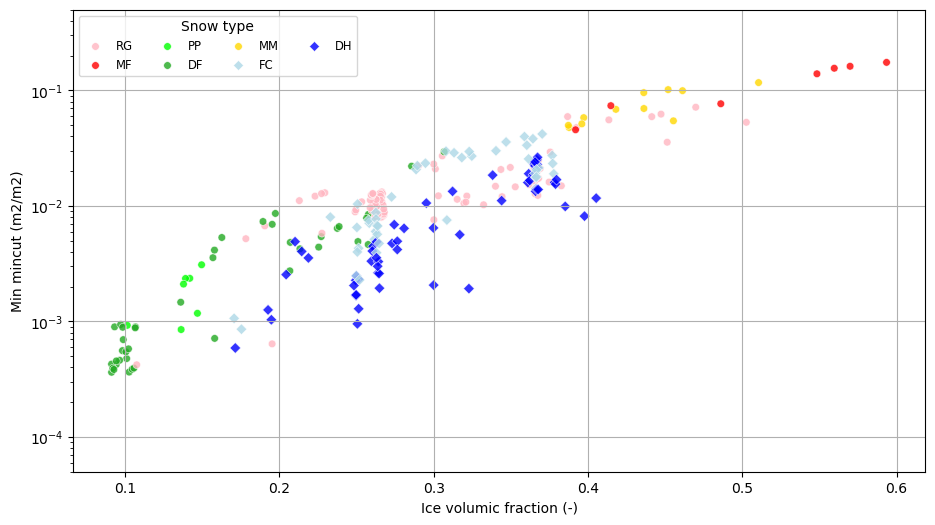

In [ ]:
mincut = "mincut_min"

## Min mincut relation to density and grain types
df_i = df[df["snowTypePrimary "].isin(["PP", "DF", "MF", "MM", "RG", "DF&RG"])]
df_wl = df[df["snowTypePrimary "].isin(["FC", "SH", "DH"])]

# sns.set(style="whitegrid", font_scale=1.3)

fig, ax = plt.subplots(figsize=(11, 6))
## All types
sns.scatterplot(ax=ax, data=df_i, x="phi", y=mincut, hue="snowTypePrimary ", palette=grain_color, s=30, alpha=0.8)

## Only PWL grain types
sns.scatterplot(ax=ax, data=df_wl, x="phi", y=mincut, hue="snowTypePrimary ", marker="D", palette=grain_color, s=30, alpha=0.8)
ax.set(yscale="log")
sns.move_legend(ax, loc="best", ncol=4, frameon=True, title="Snow type", fontsize="small")
ax.set_xlabel("Ice volumic fraction (-)")
ax.set_ylabel("Min mincut (m2/m2)")
ax.grid(True)
ax.set_ylim(0.00005, 0.5)

plt.savefig(output_path + mincut + "_vs_density_all_tomography.pdf")

## FIT between density and min mincut, with sphericity and grain size

In [79]:
###  VARIABLES
phi = df["phi"].values
mincut = df["mincut_min"].values
grain_type = df["snowTypePrimary "].values


###  FUNCTIONS
def f_phi(phi, phit, m):
    return ((phi - phit) / (1 - phit)) ** m


def alpha(S, G, a0, aS, aG, aSG):
    """Bilinear form"""
    z = a0 + aS * S + aG * G + aSG * S * G
    return 1 / (1 + np.exp(-z))


def map_latent(x_latent, low, high):
    """Transform latent variable -> interval [low, high]."""
    return low + (high - low) / (1 + np.exp(-x_latent))


def model(params, phi, mincut, grain_type):
    # Unpack fixed parameters
    a0, aS, aG, aSG, m, phit = params[:6]

    # Latent variables
    n = len(phi)
    s_latent = params[6 : 6 + n]
    g_latent = params[6 + n : 6 + 2 * n]

    pred = np.zeros(n)

    for i in range(n):
        gtype = grain_type[i]
        Smin, Smax = grain_intervals.loc[gtype]["S"]
        Gmin, Gmax = grain_intervals.loc[gtype]["G"]

        Si = map_latent(s_latent[i], Smin, Smax)
        Gi = map_latent(g_latent[i], Gmin, Gmax)

        pred[i] = alpha(Si, Gi, a0, aS, aG, aSG) * f_phi(phi[i], phit, m)

    return pred - mincut


###  FITTING
n = len(phi)
params0 = np.zeros(6 + 2 * n)  # a0,aS,aG,aSG,m + latent S,G
params0[4] = 3.0  # initial guess for m
params0[5] = 0.04  # initial guess for phit

# Bounds for the parameters
lower_bounds = np.full(6 + 2 * n, -np.inf)
upper_bounds = np.full(6 + 2 * n, np.inf)

## Bounds for m
lower_bounds[4] = 2.0
upper_bounds[4] = 4.5

## Bounds for phit
lower_bounds[5] = 0.03
upper_bounds[5] = 0.05

# Fit
res = least_squares(model, params0, args=(phi, mincut, grain_type), bounds=(lower_bounds, upper_bounds), max_nfev=10000, verbose=2)

# ------------------------
#  RESULTS
# ------------------------

p = res.x

a0, aS, aG, aSG, m, phit = np.round(p[0], 2), np.round(p[1], 2), np.round(p[2], 2), np.round(p[3], 2), np.round(p[4], 2), np.round(p[5], 2)

print(f"a0  = {a0:.2f}")
print(f"aS  = {aS:.2f}")
print(f"aG  = {aG:.2f}")
print(f"aSG = {aSG:.2f}")
print(f"m   = {m:.2f}")
print(f"phit   = {phit:.2f}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.9509e-02                                    2.56e-01    
       1              2         8.5321e-03      2.10e-02       3.03e+00       1.28e-02    
       2              3         4.6816e-03      3.85e-03       6.05e+00       4.01e-03    
       3              4         2.9860e-03      1.70e-03       1.21e+01       1.46e-02    
       4              5         1.9941e-03      9.92e-04       2.42e+01       2.08e-03    
       5              6         1.7691e-03      2.25e-04       2.42e+01       1.28e-02    
       6              7         1.6317e-03      1.37e-04       2.42e+01       8.98e-04    
       7              8         1.6056e-03      2.61e-05       4.84e+01       5.94e-03    
       8              9         1.5812e-03      2.44e-05       4.84e+01       6.21e-04    
       9             10         1.5789e-03      2.32e-06       9.68e+01       5.07e-03    

### Final parameterization

In [80]:
def f_phi(phi, phit=phit, m=m):
    return ((phi - phit) / (1 - phit)) ** m


def alpha(S, G, a0=a0, aS=aS, aG=aG, aSG=aSG):
    """Forme bilinéaire simple."""
    z = a0 + aS * S + aG * G + aSG * S * G
    return 1 / (1 + np.exp(-z))


def f_mincut_param(phi, sphericity, ssa):
    return f_phi(phi=phi) * alpha(S=sphericity, G=ssa)

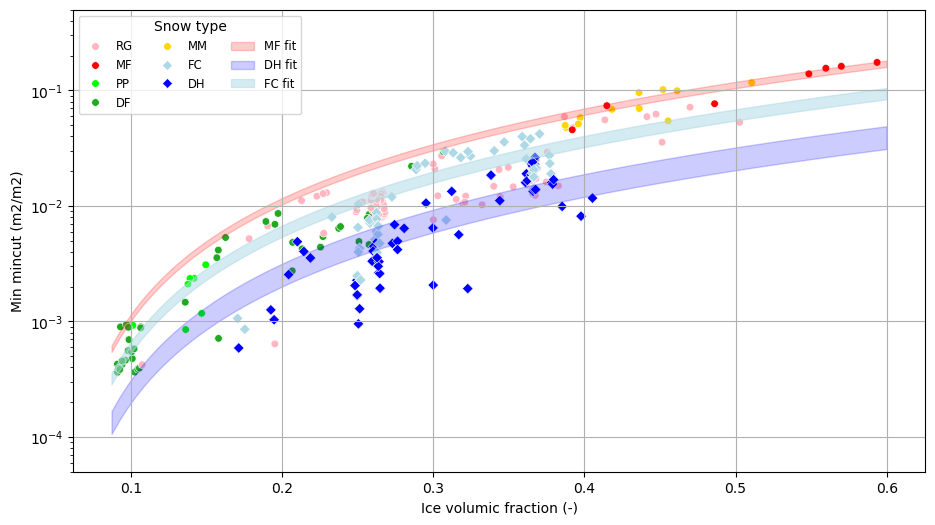

In [81]:
## Density axe
density = np.linspace(80, 550, 100)
phi = density / 917

## Min mincut relation to density and grain types
df_i = df[df["snowTypePrimary "].isin(["PP", "DF", "MF", "MM", "RG", "DF&RG"])]
df_wl = df[df["snowTypePrimary "].isin(["FC", "SH", "DH"])]

classic = "MF"

fig, ax = plt.subplots(figsize=(11, 6))

## All types
sns.scatterplot(ax=ax, data=df_i, x="phi", y="mincut_min", hue="snowTypePrimary ", palette=grain_color, s=30)

## Only PWL grain types
sns.scatterplot(ax=ax, data=df_wl, x="phi", y="mincut_min", hue="snowTypePrimary ", marker="D", palette=grain_color, s=30)
ax.set(yscale="log")

ax.fill_between(
    phi,
    y1=f_mincut_param(density / 917, grain_intervals.loc[classic]["S"][0], grain_intervals.loc[classic]["G"][0]),
    y2=f_mincut_param(density / 917, grain_intervals.loc[classic]["S"][1], grain_intervals.loc[classic]["G"][1]),
    color=grain_color[classic],
    label=classic + " fit",
    alpha=0.2,
)
ax.fill_between(
    phi,
    y1=f_mincut_param(density / 917, grain_intervals.loc["DH"]["S"][0], grain_intervals.loc["DH"]["G"][0]),
    y2=f_mincut_param(density / 917, grain_intervals.loc["DH"]["S"][1], grain_intervals.loc["DH"]["G"][1]),
    color=grain_color["DH"],
    label="DH fit",
    alpha=0.2,
)
ax.fill_between(
    phi,
    y1=f_mincut_param(density / 917, grain_intervals.loc["FC"]["S"][0], grain_intervals.loc["FC"]["G"][0]),
    y2=f_mincut_param(density / 917, grain_intervals.loc["FC"]["S"][1], grain_intervals.loc["FC"]["G"][1]),
    color=grain_color["FC"],
    label="FC fit",
    alpha=0.5,
)
ax.legend()
ax.set_xlabel("Ice volumic fraction (-)")
ax.set_ylabel("Min mincut (m2/m2)")
ax.grid(True)
sns.move_legend(ax, loc="best", ncol=3, frameon=True, title="Snow type", fontsize="small")
ax.set_ylim(0.00005, 0.5)

plt.savefig(output_path + "Min_mincut_FINAL_param_vs_density_all_tomography.pdf", dpi=300)


# Comparison with PST (Richter et al., 2019) - WFJ AND WAN7 : Results 2 and 3

In [82]:
data_path = "/home/monteirod/PostDoc_CEN/Avalanches/EXPES/"
output_path = "/home/monteirod/PostDoc_CEN/Avalanches/figures/Article_AC_parameterization/PST_comparison/"

dict_EXPE = {"WFJ2": "WFJ2_2015_2017_tassement", "WAN7": "WAN7_2014_2017_tassement"}

### Overall stratigraphy of the seasons

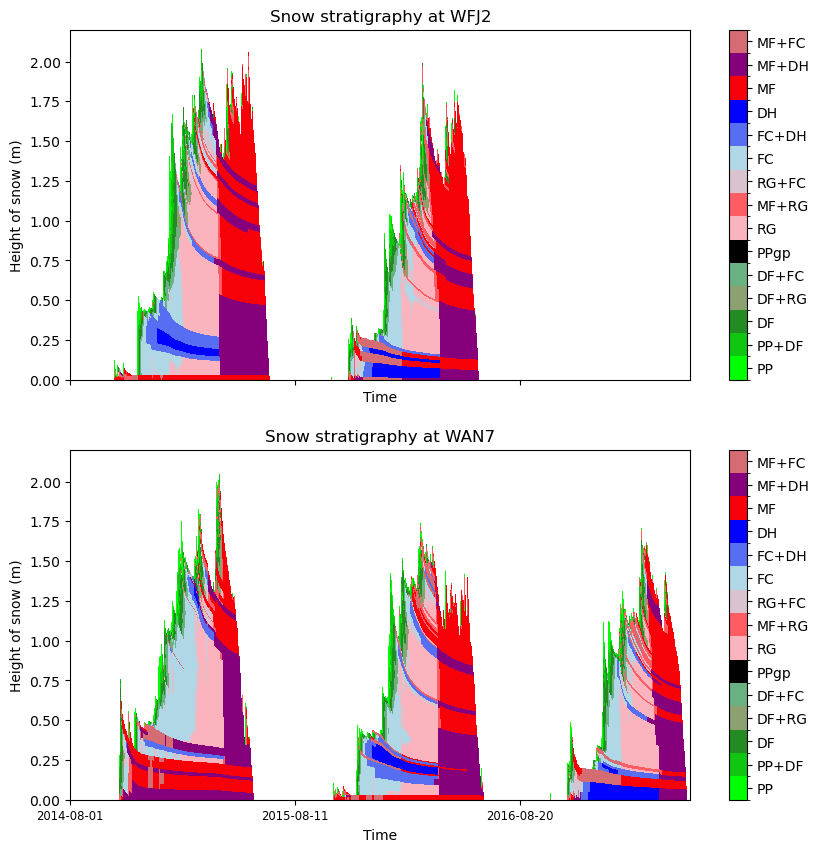

In [13]:
### Overview of the seasonal strati
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
point = 0

for i in range(0, len(list(axs.flatten()))):
    ax = axs[i]

    ## SNOWTYPE
    with prosimu_auto(glob(data_path + list(dict_EXPE.keys())[i] + "/" + dict_EXPE[list(dict_EXPE.keys())[i]] + "/pro/*")[0]) as ff:
        dz = ff.read("SNOWDZ", selectpoint=point, fill2zero=True)
        snowtype = ff.read("SNOWTYPE", selectpoint=point)
        time = ff.readtime()

    im = saisonProfil(ax, dz, snowtype, time, colormap="grains", cbar_show=True)
    ax.set_ylim(0, 2.2)
    ax.set_xlim()
    ax.set_ylabel("Height of snow (m)")
    ax.set_xlabel("Time")
    ax.set_title("Snow stratigraphy at " + list(dict_EXPE.keys())[i])

# plt.savefig(output_path + "Stratigraphy_Snowtype_all_site.png", dpi=300)


### Load PST, manual profiles and Crocus stratigraphy

In [ ]:
## Load PST and Crocus stratigraphy

start_date = {
    "WAN7": {"FC141216": "2014-12-09", "DH151201": "2015-11-26", "FC151231": "2015-12-12", "DH161224": "2016-12-15"},
    "WFJ2": {"DH151201": "2015-11-26", "FC151231": "2015-12-08", "DH161224": "2016-12-15"},
}

end_date = {
    "WAN7": {"FC141216": "2014-12-20T12", "DH151201": "2015-12-05", "FC151231": "2015-12-20", "DH161224": "2016-12-25"},
    "WFJ2": {"DH151201": "2015-12-05", "FC151231": "2015-12-28", "DH161224": "2016-12-25"},
}

### Defined color and marker for plots
marker_site = {"WAN7": "s", "WFJ2": "D"}
color_layer = {"FC141216": "orange", "SH150124": "purple", "DH151201": "royalblue", "FC151231": "indianred", "DH161224": "darkblue", "PP170218": "darkgreen", "PP170126": "green"}

### Load Crocus stratigraphy
ds = {}
for site in list(start_date.keys()):
    ds[site] = xr.load_dataset(glob(data_path + site + "/" + dict_EXPE[site] + "/pro/*")[0]).squeeze()
    ds[site]["Deposition_time"] = ds[site]["SAG_VEG"].time - ds[site]["SAG_VEG"].astype("timedelta64[D]")
    ## Compute depth of the top of the layer
    top_depth = []
    for i in range(0, len(ds[site].snow_layer)):
        top_depth.append((ds[site]["DSN_T_ISBA"] - ds[site]["SNOWDZ"].isel(snow_layer=slice(0, i)).sum(dim="snow_layer")))
    ds[site]["top_depth"] = xr.concat(top_depth, dim="snow_layer")
    ds[site]["top_depth"] = ds[site]["top_depth"].where(ds[site]["top_depth"] >= 0.0)

### Load WL and slab characteristics for each site and layer identified
ds_layer = {site: {} for site in list(start_date.keys())}
ds_slab = {site: {} for site in list(start_date.keys())}

for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        mask = (ds[site]["Deposition_time"] > np.datetime64(start_date[site][layer])) * (ds[site]["Deposition_time"] < np.datetime64(end_date[site][layer]))
        ilayer = ds[site].where(mask)
        ## We select all grain types containing at least a bit of FC or DH
        ilayer = ilayer.where(ilayer["SNOWTYPE"].isin([0, 1, 2, 4, 8, 9, 10, 11, 13, 14]))
        ilayer["SNOWDZ"] = ilayer["SNOWDZ"].sum(dim="snow_layer")
        ## For grain type we take the one that are most represented among the depth
        ilayer["SNOWTYPE"] = ("time", mode(ilayer["SNOWTYPE"], nan_policy="omit", axis=1)[0])
        ds_layer[site][layer] = ilayer.mean(dim="snow_layer")

        mask_slab = ds[site]["Deposition_time"] > np.datetime64(end_date[site][layer])
        ds_slab[site][layer] = ds[site].where(mask_slab)


In [84]:
###########################
## Load PST measurements ##
###########################


dict_PST = {"WAN7": "pst_stab_wan_2015-2016-2017.csv", "WFJ2": "pst_stab_wfj_2016-2017.csv"}

ds_PST = {site: {} for site in list(start_date.keys())}

for site in list(start_date.keys()):
    pst = pd.read_csv("/home/monteirod/PostDoc_CEN/Avalanches/DATA/AC_evaluation/Richter2019/stability_tests/" + dict_PST[site], sep=",")
    pst["date [YYYY-MM-DD]"] = pd.to_datetime(pst["date [YYYY-MM-DD]"])
    pst = pst.set_index(["date [YYYY-MM-DD]"])
    pst = pst.to_xarray().rename({"date [YYYY-MM-DD]": "time", "critical_crack_length [cm]": "ac", "dip [cm]": "depth"})

    for layer in list(start_date[site].keys()):
        ds_PST[site][layer] = pst.where(pst.layer_id == layer).dropna(dim="time")
        ds_PST[site][layer] = ds_PST[site][layer].where(ds_PST[site][layer]["ac"] < 100).dropna(dim="time")

ds_PST["WAN7"]["FC141216"] = ds_PST["WAN7"]["FC141216"].sel(time=slice("2015-01", "2015-02-13"))

###########################
## Load MAN measurements ##
###########################

dict_manprof = {"WAN7": "wan", "WFJ2": "wfj"}


def E_modulus(rho):
    return 6.5e9 * (rho / 917) ** 4.4


def E_modulus_gaume(rho):
    return 5.07e9 * (rho / 917) ** 5.13


def E_modulus_viallon(rho):
    return 1.85e5 * np.exp(rho / 67)


ds_obs = {site: {} for site in list(start_date.keys())}
ds_manual_complete = {site: {} for site in list(start_date.keys())}

for site in list(start_date.keys()):
    ds_manual_complete[site] = []
    for layer in list(start_date[site].keys()):
        ds_obs[site][layer] = []
        for time in np.unique(ds_PST[site][layer].time):
            time = pd.to_datetime(str(time))
            time = time.strftime("%Y%m%d")

            strati = pd.read_csv(
                "/home/monteirod/PostDoc_CEN/Avalanches/DATA/AC_evaluation/Richter2019/manual_profiles/" + dict_manprof[site] + "_" + time + ".txt",
                sep=" ",
            )
            strati.columns = list(strati.columns)[1:] + ["None"]
            strati = strati.iloc[1:]
            strati["density"] = strati["density"].where(strati["density"].astype("float") > 0, 917)
            strati = strati.astype(float)
            strati["depth"] = strati["depth"] / 100
            strati["thickness"] = strati["thickness"] / 100
            strati = strati.set_index("depth").to_xarray()
            strati = strati.rename({"thickness": "SNOWDZ", "density": "RSN_VEG"})

            ## For manual profiles plot
            strati["grain_type1"] = strati["grain_type1"][1:].astype("float")
            strati["grain_type2"] = strati["grain_type2"][1:].astype("float")
            strati["grain_type1"] = strati["grain_type1"].where(strati["grain_type1"] != 0).bfill(dim="depth")
            strati["grain_type2"] = strati["grain_type2"].fillna(0)
            strati["grain_type2"] = strati["grain_type2"].where(strati["grain_type2"] != 0, strati["grain_type1"])
            hand_hardness = np.asarray(strati["hand_hardness"][1:].astype("float"))

            dict_conv = {1: "PP", 2: "DF", 3: "RG", 4: "FC", 5: "DH", 6: "SH", 7: "MF", 8: "IF", 9: "FCxr", 10: "MFcr"}

            strati["grain_type"] = ("depth", strati["grain_type1"].values.astype(int))
            strati["grain_type1"] = ("depth", [dict_conv[i] for i in strati["grain_type1"].values.astype(int)])
            strati["grain_type2"] = ("depth", [dict_conv[i] for i in strati["grain_type2"].values.astype(int)])

            strati = strati.expand_dims("time")
            strati["time"] = [pd.to_datetime(time)]

            ## Look for the depth of the top of the WL in PST
            top_layer = ds_PST[site][layer]["depth"].sel(time=time).values.mean() / 100
            # Find the corresponding indices in the observed strati
            idx = int(np.abs(strati["depth"] - top_layer).argmin())

            # ## Get the stratigraphy slab and WL
            slab = strati.isel(depth=slice(0, idx))
            wl = strati.isel(depth=idx)

            slab["S_HSLAB"] = slab["SNOWDZ"].sum(dim="depth")
            slab["S_RHOSLAB"] = np.sum(slab["RSN_VEG"] * slab["SNOWDZ"]) / slab["S_HSLAB"]
            slab["S_ELAYER"] = E_modulus(wl["RSN_VEG"])
            slab["S_HWL"] = wl["SNOWDZ"]
            slab["S_RHOWL"] = wl["RSN_VEG"]
            slab["grain_type"] = wl["grain_type"]
            slab["grain_type1"] = wl["grain_type1"]
            slab["grain_type2"] = wl["grain_type2"]

            ds_obs[site][layer].append(slab)

            ## Store complete manual profiles
            ds_manual_complete[site].append(strati)

        ds_obs[site][layer] = xr.concat(ds_obs[site][layer], dim="time")
        ds_obs[site][layer] = ds_obs[site][layer].sortby("depth", ascending=False)

    ds_manual_complete[site] = xr.concat(ds_manual_complete[site], dim="time")
    ds_manual_complete[site] = ds_manual_complete[site].sortby("depth", ascending=False)


In [ ]:
### Function to compute Wf from WEAC with density/thickness profile
def compute_wf_weac(rho, dz, ac=1000, t=30, E=0.15, inclination=40.0):
    profile_i = list(np.stack([rho, dz * 1000], axis=1))

    ### Compute Wf using weac package
    pst_cut_right = weac.Layered(system="pst-", layers=profile_i, touchdown=False)
    pst_cut_right.set_foundation_properties(t=t, E=E)  # mm, MPa
    pst_cut_right.calc_fundamental_system()

    # Input
    inclination = -inclination  # Slope inclination (°)
    totallength = 2000

    # Initialize outputs and crack lengths
    Gdif = np.zeros([3, len(ac)])
    # Ginc = np.zeros([3, len(ac)])

    # Loop through crack lengths
    for i, a in enumerate(ac):
        # Obtain lists of segment lengths, locations of foundations.
        seg_err = pst_cut_right.calc_segments(L=totallength, a=a)

        # Assemble system and solve for free constants
        C0 = pst_cut_right.assemble_and_solve(phi=inclination, **seg_err["nocrack"])
        C1 = pst_cut_right.assemble_and_solve(phi=inclination, **seg_err["crack"])

        # Compute differential and incremental energy release rates
        Gdif[:, i] = pst_cut_right.gdif(C1, inclination, **seg_err["crack"])
        # Ginc[:, i] = pst_cut_right.ginc(C0, C1, inclination, **seg_err["both"])

    return ac, Gdif[:, :] * 1e3


### Function to compute Wf from heierli with density/thickness profile
def compute_wf_heierli_from_profile(rho, dz, ac=1000, inclination=40.0, nu=0.25, gamma=1):
    hslab = np.sum(dz)
    rhoslab = np.sum(rho * dz) / hslab

    # eslab = (np.sum(dz * E_modulus(rho) ** (1 / 3)) / hslab) ** 3

    ## Equivalent slab modulus in mode I according to Rosendahl and Weissgraeber (2023)
    zib = (np.cumsum(dz[::-1])[::-1] - dz - hslab / 2) * (-1)
    zit = (np.cumsum(dz[::-1])[::-1] - hslab / 2) * (-1)
    eslab = 4 * np.sum(E_modulus(rho) * (zib**3 - zit**3)) / hslab**3

    normalstress = rhoslab * 9.81 * hslab * np.cos(np.deg2rad(inclination))
    shearstress = rhoslab * 9.81 * hslab * np.sin(np.deg2rad(inclination))

    eta = np.sqrt(4 * (1 + nu) / 5)

    w0 = (3 * (eta**2) / 4) * (shearstress**2)
    w1 = (np.pi * gamma + 3 * eta / 2) * (shearstress**2) + 3 * (eta**2) * normalstress * shearstress + np.pi * gamma * normalstress**2
    w2 = shearstress**2 + (9 * eta / 2) * normalstress * shearstress + 3 * eta**2 * normalstress**2
    w3 = 3 * eta * normalstress**2
    w4 = 3 * normalstress**2

    wf = np.zeros(len(ac))

    for i, a in enumerate(ac):
        a = a / 1000
        wf[i] = (hslab / (2 * eslab)) * (w0 + w1 * (a / hslab) + w2 * (a / hslab) ** 2 + w3 * (a / hslab) ** 3 + w4 * (a / hslab) ** 4)

    return ac, wf


### Function to compute AC from heierli with density/thickness profile
def compute_ac_heierli_from_profile(rho, dz, wf, inclination=40.0, nu=0.25, gamma=1):
    hslab = np.sum(dz)
    rhoslab = np.sum(rho * dz) / hslab

    # eslab = (np.sum(dz * E_modulus(rho) ** (1 / 3)) / hslab) ** 3

    ## Equivalent slab modulus in mode I according to Rosendahl and Weissgraeber (2023)
    zib = (np.cumsum(dz[::-1])[::-1] - dz - hslab / 2) * (-1)
    zit = (np.cumsum(dz[::-1])[::-1] - hslab / 2) * (-1)
    eslab = 4 * np.sum(E_modulus(rho) * (zib**3 - zit**3)) / hslab**3

    normalstress = rhoslab * 9.81 * hslab * np.cos(np.deg2rad(inclination))
    shearstress = rhoslab * 9.81 * hslab * np.sin(np.deg2rad(inclination))

    eta = np.sqrt(4 * (1 + nu) / 5)

    w0 = (3 * (eta**2) / 4) * (shearstress**2)
    w1 = (np.pi * gamma + 3 * eta / 2) * (shearstress**2) + 3 * (eta**2) * normalstress * shearstress + np.pi * gamma * normalstress**2
    w2 = shearstress**2 + (9 * eta / 2) * normalstress * shearstress + 3 * eta**2 * normalstress**2
    w3 = 3 * eta * normalstress**2
    w4 = 3 * normalstress**2

    p4 = 1 / (2 * eslab) * w4 / (hslab**3)
    p3 = 1 / (2 * eslab) * w3 / (hslab**2)
    p2 = 1 / (2 * eslab) * w2 / hslab
    p1 = 1 / (2 * eslab) * w1
    p0 = hslab / (2 * eslab) * w0 - wf

    ## Defined vector
    data = np.array(np.zeros(5))
    data[0] = p4
    data[1] = p3
    data[2] = p2
    data[3] = p1
    data[4] = p0

    ## Compute roots
    roots = quartic_roots(data)

    ## Get minimum real positive roots
    mask = np.isfinite(roots) & np.isreal(roots) & (roots.real > 0)
    rootsm = np.ma.array(roots.real, mask=~mask)
    ac = np.nanmin(rootsm, axis=-1).filled(np.nan)

    return float(ac)


def f_phi(phi, phit=phit, m=m):
    return ((phi - phit) / (1 - phit)) ** m


def alpha(S, G, a0=a0, aS=aS, aG=aG, aSG=aSG):
    """Forme bilinéaire simple."""
    z = a0 + aS * S + aG * G + aSG * S * G
    return 1 / (1 + np.exp(-z))


def f_mincut_param(phi, sphericity, ssa):
    return f_phi(phi=phi) * alpha(S=sphericity, G=ssa)


### Fit for Wf = f(mincut)
def f_wf_mincut(x, a):
    return a * x

### Stratigraphy charac : OBS vs MOD

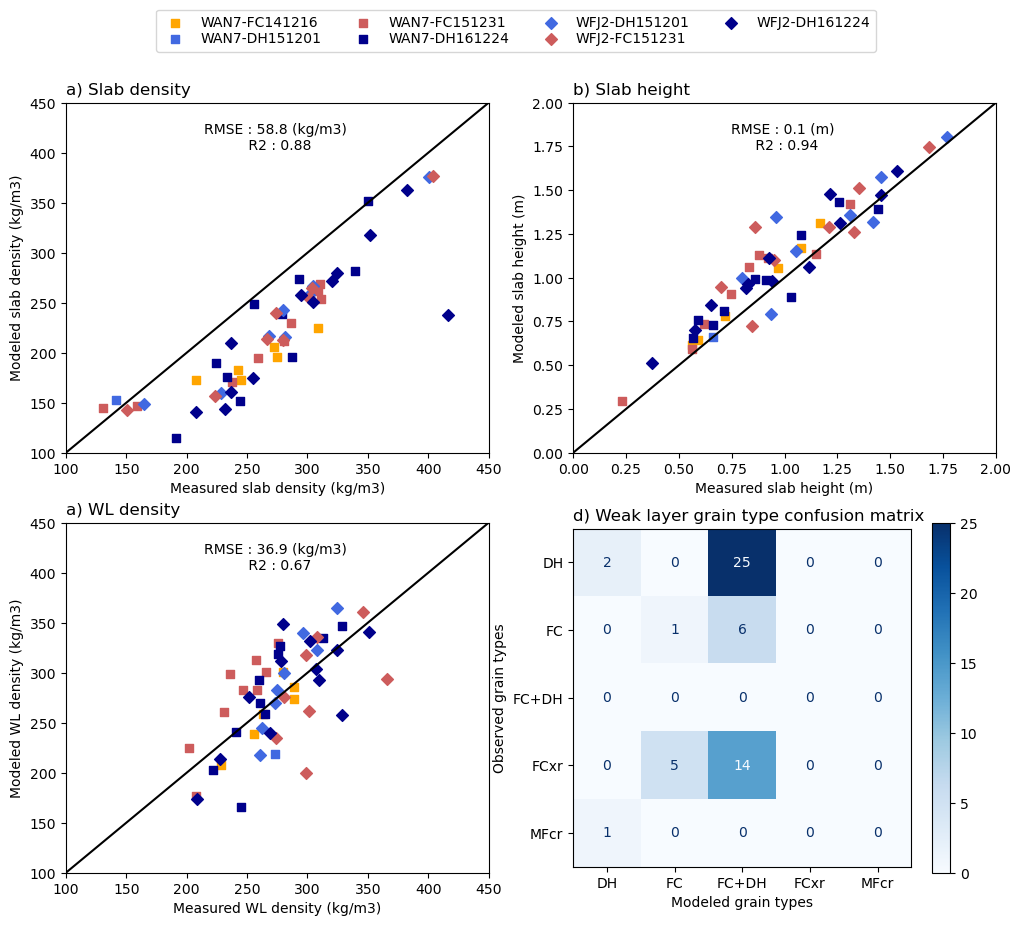

In [66]:
fig = plt.figure(figsize=(12, 10))

#####################################################

ax = fig.add_subplot(2, 2, 1)

ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## Slab density
        mod_slab = ds_layer[site][layer]["S_RHOSLAB"].sel(time=ds_obs[site][layer].time)
        ax.scatter(ds_obs[site][layer]["S_RHOSLAB"], mod_slab, marker=marker_site[site], color=color_layer[layer], label=site + "-" + layer)
        ls_mod.append(mod_slab)
        ls_obs.append(ds_obs[site][layer]["S_RHOSLAB"])

ls_mod, ls_obs = np.concatenate(ls_mod), np.concatenate(ls_obs)
ax.text(
    0.5,
    0.9,
    "RMSE : " + str(np.round(float(np.sqrt(np.mean((ls_mod - ls_obs) ** 2))), 1)) + " (kg/m3) \n R2 : " + str(np.round(np.corrcoef((ls_obs, ls_mod))[0][1], 2)),
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(100, 450)
ax.set_ylim(100, 450)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="k")
ax.set_xlabel("Measured slab density (kg/m3)")
ax.set_ylabel("Modeled slab density (kg/m3)")
ax.set_title("a) Slab density", loc="left")

#####################################################

ax = fig.add_subplot(2, 2, 2)
ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## Slab height
        mod_slab = ds_layer[site][layer]["S_HSLAB"].sel(time=ds_obs[site][layer].time, method="nearest")
        ax.scatter(ds_obs[site][layer]["S_HSLAB"], mod_slab, marker=marker_site[site], color=color_layer[layer], label=site + "-" + layer)
        ls_mod.append(mod_slab)
        ls_obs.append(ds_obs[site][layer]["S_HSLAB"])

ls_mod, ls_obs = np.concatenate(ls_mod), np.concatenate(ls_obs)
ax.text(
    0.5,
    0.9,
    "RMSE : " + str(np.round(float(np.sqrt(np.mean((ls_mod - ls_obs) ** 2))), 1)) + " (m) \n R2 : " + str(np.round(np.corrcoef((ls_obs, ls_mod))[0][1], 2)),
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="k")
ax.set_xlabel("Measured slab height (m)")
ax.set_ylabel("Modeled slab height (m)")
ax.set_title("b) Slab height", loc="left")

#####################################################
ax = fig.add_subplot(2, 2, 3)
ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## WL density
        mod_wl = ds_layer[site][layer]["RSN_VEG"].sel(time=ds_obs[site][layer].time)
        ax.scatter(ds_obs[site][layer]["S_RHOWL"], mod_wl, marker=marker_site[site], color=color_layer[layer], label=site + "-" + layer)
        ls_mod.append(mod_wl)
        ls_obs.append(ds_obs[site][layer]["S_RHOWL"])

ls_mod, ls_obs = np.concatenate(ls_mod), np.concatenate(ls_obs)
ax.text(
    0.5,
    0.9,
    "RMSE : " + str(np.round(float(np.sqrt(np.mean((ls_mod - ls_obs) ** 2))), 1)) + " (kg/m3) \n R2 : " + str(np.round(np.corrcoef((ls_obs, ls_mod))[0][1], 2)),
    horizontalalignment="center",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(100, 450)
ax.set_ylim(100, 450)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="k")
ax.set_xlabel("Measured WL density (kg/m3)")
ax.set_ylabel("Modeled WL density (kg/m3)")
ax.set_title("a) WL density", loc="left")


handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, labelspacing=0.2, bbox_to_anchor=(0.5, 0.98))


#####################################################
ax = fig.add_subplot(2, 2, 4)
ls_mod = []
ls_obs = []
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ## WL density
        mod_wl = ds_layer[site][layer]["SNOWTYPE"].sel(time=ds_obs[site][layer].time)
        ls_mod.append(mod_wl)
        ls_obs.append(ds_obs[site][layer]["grain_type"])

ls_mod, ls_obs = np.concatenate(ls_mod).astype(int), np.concatenate(ls_obs).astype(int)

dict_conv = {1: "PP", 2: "DF", 3: "RG", 4: "FC", 5: "DH", 6: "SH", 7: "MF", 8: "IF", 9: "FCxr", 10: "MFcr"}
ls_obs = [dict_conv[i] for i in ls_obs]

dict_crocus = {0: "PP", 1: "PP+DF", 2: "DF", 3: "DF+RG", 4: "DF+FC", 5: "PPgp", 6: "RG", 7: "MF+RF", 8: "RG+FC", 9: "FC", 10: "FC+DH", 11: "DH", 12: "MF", 13: "MF+DH", 14: "MF+FC"}
ls_mod = [dict_crocus[i] for i in ls_mod]

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute confusion matrix
labels = sorted(list(set(ls_obs) | set(ls_mod)))
cm = confusion_matrix(ls_obs, ls_mod, labels=labels)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d", ax=ax)

# Customize axis titles
ax.set_xlabel("Modeled grain types")
ax.set_ylabel("Observed grain types")

# Plot title
ax.set_title("d) Weak layer grain type confusion matrix", loc="left")

fig.savefig(output_path + "Slab_WL_charact_Observed_vs_Crocus.pdf", bbox_inches="tight")


## Comparison Wf and AC using WEAC/Heierli model vs Mincut : Results 2

In [86]:
def compute_both_wf(slab, wl, WL_type, dim, MODEL="weac", fondation="EWL_t_default"):
    ############################
    ## INITIALISATION
    ############################
    wf_weac = {site: {} for site in start_date}
    wf_heierli = {site: {} for site in start_date}
    ac_mod = {site: {} for site in start_date}

    ############################
    ## WF computation with INVERSION of SLAB MODEL
    ############################
    for site in start_date:
        for layer in start_date[site]:
            wf_weac[site][layer] = []
            wf_heierli[site][layer] = []
            ac_mod[site][layer] = []

            for time in np.unique(ds_PST[site][layer].time):
                profile_i = slab[site][layer].sel(time=time).squeeze()[["RSN_VEG", "SNOWDZ"]].dropna(dim=dim)

                rho = profile_i["RSN_VEG"].values
                dz = profile_i["SNOWDZ"].values
                inclination = 0

                # Weak layer mechanical properties
                if fondation == "E_t_default":
                    E, t = 0.15, 20
                elif fondation == "EWL_t_default":
                    E = float(wl[site][layer].sel(time=time)["S_ELAYER"] / 1e6)
                    t = 30
                elif fondation == "E_t_WL":
                    E = float(wl[site][layer].sel(time=time)["S_ELAYER"] / 1e6)
                    t = float(wl[site][layer].sel(time=time)["SNOWDZ"] * 1000)

                ac = [ds_PST[site][layer].sel(time=time)["ac"].mean().values * 10]

                ac_h, wf_h = compute_wf_heierli_from_profile(rho=rho, ac=ac, dz=dz, inclination=inclination)
                ac_w, wf_w = compute_wf_weac(rho=rho, dz=dz, ac=ac, t=t, E=E, inclination=inclination)

                wf_heierli[site][layer].append(float(wf_h))
                wf_weac[site][layer].append(float(wf_w[0]))
                ac_mod[site][layer].append(float(ac[0]))

            times = np.unique(ds_PST[site][layer].time)
            wf_heierli[site][layer] = xr.DataArray(wf_heierli[site][layer], dims="time", coords={"time": times})
            wf_weac[site][layer] = xr.DataArray(wf_weac[site][layer], dims="time", coords={"time": times})
            ac_mod[site][layer] = xr.DataArray(ac_mod[site][layer], dims="time", coords={"time": times})

    ############################
    ## CHOIX DU MODELE WF
    ############################
    wf = {site: {} for site in start_date}

    if MODEL == "heierli":
        for site in start_date:
            for layer in start_date[site]:
                wf[site][layer] = wf_heierli[site][layer]
    else:
        for site in start_date:
            for layer in start_date[site]:
                wf[site][layer] = wf_weac[site][layer]

    ############################
    ## FONCTIONS UTILITAIRES
    ############################
    def build_grain_characteristics(bnd):
        SPHERICITY = {layer: grain_intervals.loc[layer[:2]]["S"][bnd] for layer in ["FC141216", "DH151201", "FC151231", "DH161224"]}
        SNOWSSA = {layer: grain_intervals.loc[layer[:2]]["G"][bnd] for layer in ["FC141216", "DH151201", "FC151231", "DH161224"]}
        return SPHERICITY, SNOWSSA

    def compute_fit(WL_charact):
        ls_mincut, ls_wf = [], []

        for site in start_date:
            for layer in start_date[site]:
                ls_mincut.append(
                    f_mincut_param(
                        WL_charact[site][layer]["S_RHOWL"] / 917,
                        WL_charact[site][layer]["SNOWSPHER"],
                        WL_charact[site][layer]["SNOWSSA"],
                    )
                )
                ls_wf.append(wf[site][layer])

        x = np.concatenate(ls_mincut)
        y = np.concatenate(ls_wf)

        popt, _ = curve_fit(f_wf_mincut, x, y)
        r2 = np.corrcoef(x, y)[0, 1]

        return popt, r2

    ############################
    ## CAS WL OBS : INTERVALLES
    ############################
    popt = {}
    r2 = {}
    if WL_type == "OBS":
        for bnd, label in zip([0, 1], ["lower", "upper"]):
            SPHERICITY, SNOWSSA = build_grain_characteristics(bnd)
            WL_charact = {site: {} for site in start_date}

            for site in start_date:
                for layer in start_date[site]:
                    WL_charact[site][layer] = wl[site][layer].sel(time=np.unique(ds_PST[site][layer].time))
                    n = len(WL_charact[site][layer].time)
                    WL_charact[site][layer]["SNOWSPHER"] = ("time", np.ones(n) * SPHERICITY[layer])
                    WL_charact[site][layer]["SNOWSSA"] = ("time", np.ones(n) * SNOWSSA[layer])

            popt[label], r2[label] = compute_fit(WL_charact)

        return ac_mod, WL_charact, wf, popt, r2

    ############################
    ## CAS WL CROCUS
    ############################
    else:
        WL_charact = {site: {} for site in start_date}
        for site in start_date:
            for layer in start_date[site]:
                WL_charact[site][layer] = wl[site][layer].sel(time=np.unique(ds_PST[site][layer].time))
                WL_charact[site][layer]["S_RHOWL"] = WL_charact[site][layer]["RSN_VEG"]
                WL_charact[site][layer]["S_HWL"] = WL_charact[site][layer]["SNOWDZ"]

        popt, r2 = compute_fit(WL_charact)
        return ac_mod, WL_charact, wf, popt, r2


### Using manual and crocus profiles

In [87]:
# Date of deposition of each layers in Crocus
start_date = {
    "WAN7": {"FC141216": "2014-12-09", "DH151201": "2015-11-26", "FC151231": "2015-12-12", "DH161224": "2016-12-15"},
    "WFJ2": {"DH151201": "2015-11-26", "FC151231": "2015-12-08", "DH161224": "2016-12-15"},
}

end_date = {
    "WAN7": {"FC141216": "2014-12-20T12", "DH151201": "2015-12-05", "FC151231": "2015-12-20", "DH161224": "2016-12-25"},
    "WFJ2": {"DH151201": "2015-12-05", "FC151231": "2015-12-28", "DH161224": "2016-12-25"},
}

MODEL = "weac"
fondation = "EWL_t_default"
inclination = 0

ac_mod_crocus, WL_charact_crocus, wf_crocus, popt_crocus, r2_crocus = compute_both_wf(ds_slab, ds_layer, WL_type="crocus", dim="snow_layer", MODEL=MODEL, fondation=fondation)

ac_mod_OBS, WL_charact_OBS, wf_OBS, popt_OBS, r2_OBS = compute_both_wf(ds_obs, ds_obs, WL_type="OBS", dim="depth", MODEL=MODEL, fondation=fondation)

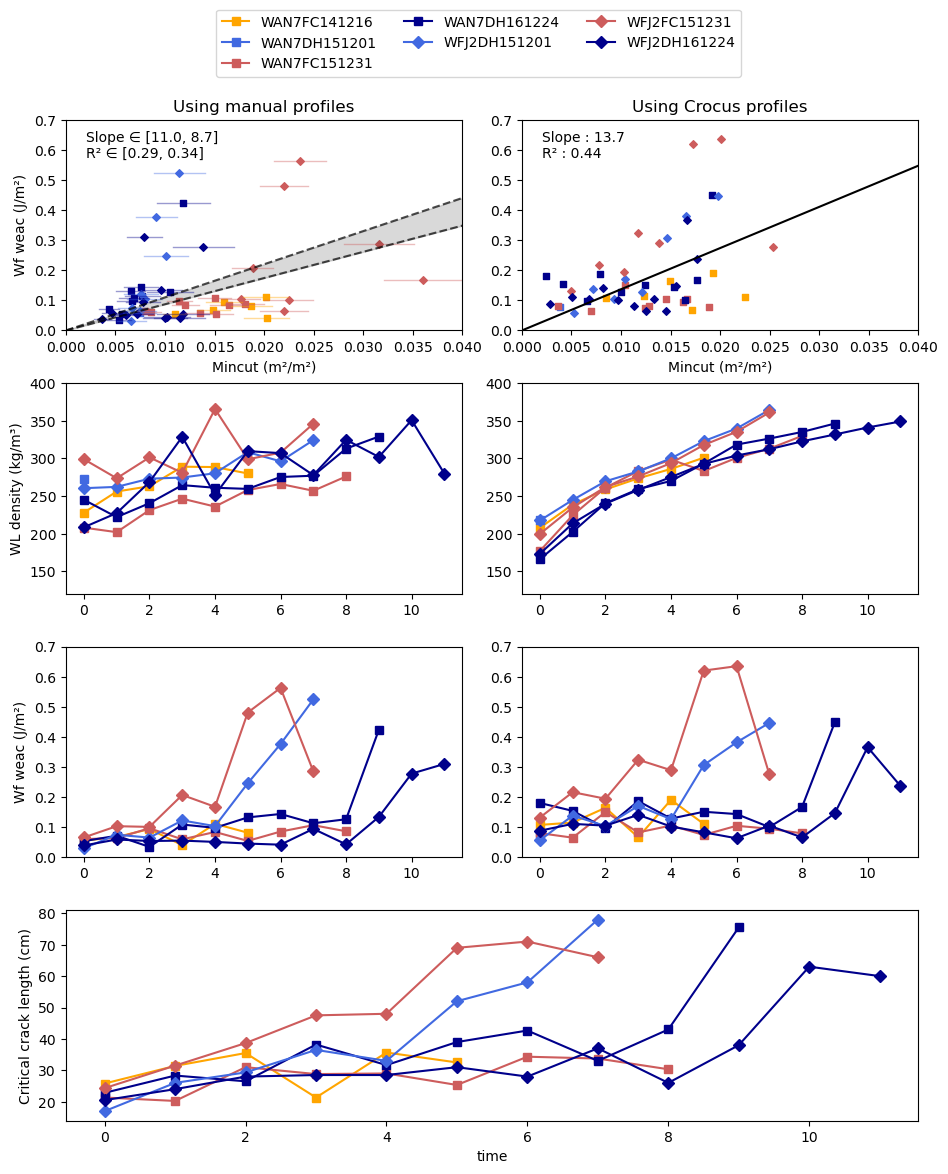

In [89]:
def compute_mc_interval(WL_layer, grain_interval):
    """Return min/max mincut as xarray DataArray"""
    mc_min = f_mincut_param(
        WL_layer["S_RHOWL"] / 917,
        grain_interval["S"][0],
        grain_interval["G"][0],
    )
    mc_max = f_mincut_param(
        WL_layer["S_RHOWL"] / 917,
        grain_interval["S"][1],
        grain_interval["G"][1],
    )
    return mc_min, mc_max


def plot_mc_interval(ax, mc_min, mc_max, wf, color):
    """Plot horizontal uncertainty bars"""
    for i in range(len(wf)):
        ax.plot(
            [mc_min[i], mc_max[i]],
            [wf[i], wf[i]],
            color=color,
            alpha=0.4,
            linewidth=1,
        )


def iter_layers(start_date):
    for site in start_date:
        for layer in start_date[site]:
            yield site, layer


def plot_timeseries(ax, data, ylabel=None):
    for site, layer in iter_layers(start_date):
        ax.plot(
            np.arange(len(data[site][layer])),
            data[site][layer],
            marker=marker_site[site],
            color=color_layer[layer],
            label=site + layer,
        )
    if ylabel:
        ax.set_ylabel(ylabel)


fig = plt.figure(figsize=(11, 13))

wf_lim = 0.7
mincut_lim = 0.04
xfit = np.linspace(0, mincut_lim, 200)


## For OBS
ax = fig.add_subplot(4, 2, 1)

for site, layer in iter_layers(start_date):
    grain_key = layer[:2]
    mc_min, mc_max = compute_mc_interval(WL_charact_OBS[site][layer], grain_intervals.loc[grain_key])

    wf_vals = wf_OBS[site][layer]
    mc_mid = 0.5 * (mc_min + mc_max)

    ax.scatter(
        mc_mid,
        wf_vals,
        marker=marker_site[site],
        color=color_layer[layer],
        s=15,
    )

    plot_mc_interval(ax, mc_min, mc_max, wf_vals, color_layer[layer])

# Fits + envelope
ax.plot(xfit, f_wf_mincut(xfit, popt_OBS["lower"][0]), "k--", alpha=0.7)
ax.plot(xfit, f_wf_mincut(xfit, popt_OBS["upper"][0]), "k--", alpha=0.7)
ax.fill_between(
    xfit,
    f_wf_mincut(xfit, popt_OBS["lower"][0]),
    f_wf_mincut(xfit, popt_OBS["upper"][0]),
    color="k",
    alpha=0.15,
)

ax.text(
    0.05,
    0.95,
    f"Slope ∈ [{popt_OBS['lower'][0]:.1f}, {popt_OBS['upper'][0]:.1f}]\nR² ∈ [{r2_OBS['lower']:.2f}, {r2_OBS['upper']:.2f}]",
    transform=ax.transAxes,
    va="top",
)

ax.set(
    xlabel="Mincut (m²/m²)",
    ylabel=f"Wf {MODEL} (J/m²)",
    xlim=(0, mincut_lim),
    ylim=(0, wf_lim),
    title="Using manual profiles",
)

## For CROCUS
ax = fig.add_subplot(4, 2, 2)

for site, layer in iter_layers(start_date):
    mc = f_mincut_param(
        WL_charact_crocus[site][layer]["S_RHOWL"] / 917,
        WL_charact_crocus[site][layer]["SNOWSPHER"],
        WL_charact_crocus[site][layer]["SNOWSSA"],
    )

    ax.scatter(
        mc,
        wf_crocus[site][layer],
        marker=marker_site[site],
        color=color_layer[layer],
        s=15,
    )

ax.plot(xfit, f_wf_mincut(xfit, popt_crocus[0]), "k")
ax.text(
    0.05,
    0.95,
    f"Slope : {popt_crocus[0]:.1f}\nR² : {r2_crocus:.2f}",
    transform=ax.transAxes,
    va="top",
)

ax.set(
    xlabel="Mincut (m²/m²)",
    xlim=(0, mincut_lim),
    ylim=(0, wf_lim),
    title="Using Crocus profiles",
)

## WL density
ax = fig.add_subplot(4, 2, 3)
plot_timeseries(ax, {s: {l: WL_charact_OBS[s][l]["S_RHOWL"] for l in start_date[s]} for s in start_date}, "WL density (kg/m³)")
ax.set_ylim(120, 400)

ax = fig.add_subplot(4, 2, 4)
plot_timeseries(ax, {s: {l: WL_charact_crocus[s][l]["S_RHOWL"] for l in start_date[s]} for s in start_date})
ax.set_ylim(120, 400)

## WL evolution
ax = fig.add_subplot(4, 2, 5)
plot_timeseries(ax, wf_OBS, f"Wf {MODEL} (J/m²)")
ax.set_ylim(0, wf_lim)

ax = fig.add_subplot(4, 2, 6)
plot_timeseries(ax, wf_crocus)
ax.set_ylim(0, wf_lim)

## AC evolution
ax = fig.add_subplot(4, 1, 4)
plot_timeseries(ax, {s: {l: ac_mod_OBS[s][l] / 10 for l in start_date[s]} for s in start_date}, "Critical crack length (cm)")
ax.set_xlabel("time")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.97))

plt.subplots_adjust(wspace=0.15, hspace=0.25)

plt.savefig(output_path + "Wf_Mincut_Crocus_and_OBS_profiles_WL_weac_" + fondation + "_slope_" + str(inclination) + ".pdf")

plt.show()


### AC OBS vs. MOD : Weac and Heierli

In [ ]:
# fondation = "E_t_default"
fondation = "EWL_t_default"
# fondation = "E_t_WL"

WL = "crocus"  # "crocus" ou "OBS"

if WL == "crocus":
    popt_weac = float(np.round(popt_crocus, 1))
    popt_heierli = float(np.round(popt_crocus, 1))
elif WL == "OBS":
    popt_weac = float(np.round((popt_OBS["lower"] + popt_OBS["upper"]) / 2, 1))
    popt_heierli = float(np.round((popt_OBS["lower"] + popt_OBS["upper"]) / 2, 1))

inclination = 0


# Fonctions
# =========


def compute_wf_from_charact(WL_charact_t, popt):
    return float(
        f_wf_mincut(
            f_mincut_param(
                WL_charact_t["S_RHOWL"] / 917,
                WL_charact_t["SNOWSPHER"],
                WL_charact_t["SNOWSSA"],
            ),
            popt,
        )
    )


def invert_ac_weac(rho, dz, wf_target, E, t, inclination, ac_bounds=(0.01, 3000), tol=0.01):
    inf, sup = ac_bounds
    m = 0.5 * (inf + sup)
    wf_weac = [0.0]

    while abs((wf_weac[0] - wf_target) / wf_target) > tol:
        ac_weac, wf_weac = compute_wf_weac(rho=rho, dz=dz, ac=[m], t=t, E=E, inclination=inclination)
        if wf_weac[0] <= wf_target:
            inf = m
        else:
            sup = m
        m = 0.5 * (inf + sup)

    return float(ac_weac[0] / 10)


def compute_ac_interval_time(
    rho,
    dz,
    WL_charact_t,
    sph_bounds,
    ssa_bounds,
    popt_weac,
    popt_heierli,
    E,
    t,
    inclination,
    WL,
):
    ac_weac_vals = []
    ac_heierli_vals = []

    # CROCUS
    # ==========================
    if WL == "crocus":
        sph = float(WL_charact_t["SNOWSPHER"])
        ssa = float(WL_charact_t["SNOWSSA"])

        WL_tmp = WL_charact_t.copy()
        WL_tmp["SNOWSPHER"] = sph
        WL_tmp["SNOWSSA"] = ssa

        # --- WEAC
        wf = compute_wf_from_charact(WL_tmp, popt_weac)
        # wf = 0.15
        ac_weac = invert_ac_weac(rho, dz, wf, E, t, inclination)

        # --- Heierli
        wf = compute_wf_from_charact(WL_tmp, popt_heierli)
        # wf = 0.15
        ac_heierli = compute_ac_heierli_from_profile(rho=rho, dz=dz, wf=wf, inclination=inclination) * 100

        return ac_weac, ac_weac, ac_heierli, ac_heierli

    # OBS : intervals
    # ==========================
    for sph, ssa in product(sph_bounds, ssa_bounds):
        WL_tmp = WL_charact_t.copy()
        WL_tmp["SNOWSPHER"] = sph
        WL_tmp["SNOWSSA"] = ssa

        # --- WEAC
        wf = compute_wf_from_charact(WL_tmp, popt_weac)
        # wf = 0.15

        ac_weac_vals.append(invert_ac_weac(rho, dz, wf, E, t, inclination))

        # --- Heierli
        wf = compute_wf_from_charact(WL_tmp, popt_heierli)
        # wf = 0.15

        ac_heierli_vals.append(compute_ac_heierli_from_profile(rho=rho, dz=dz, wf=wf, inclination=inclination) * 100)

    return (
        min(ac_weac_vals),
        max(ac_weac_vals),
        min(ac_heierli_vals),
        max(ac_heierli_vals),
    )


# ==============================

ac_W_interval = {site: {} for site in start_date}
ac_H_interval = {site: {} for site in start_date}
WL_charact = {site: {} for site in list(start_date.keys())}


for site in start_date:
    for layer in start_date[site]:
        ac_W_interval[site][layer] = []
        ac_H_interval[site][layer] = []

        sph_bounds = grain_intervals.loc[layer[0:2]]["S"]  # [min, max]
        ssa_bounds = grain_intervals.loc[layer[0:2]]["G"]  # [min, max]

        for time in np.unique(ds_PST[site][layer].time):
            # ---------- WL & slab characteristics
            if WL == "crocus":
                ds_layer[site][layer]["S_RHOWL"] = ds_layer[site][layer]["RSN_VEG"]
                ds_layer[site][layer]["S_HWL"] = ds_layer[site][layer]["SNOWDZ"]
                WL_charact[site][layer] = ds_layer[site][layer].sel(time=np.unique(ds_PST[site][layer].time)).sel(time=time)
                profile_i = ds_slab[site][layer].sel(time=time).squeeze()[["RSN_VEG", "SNOWDZ"]].dropna(dim="snow_layer")

            elif WL == "OBS":
                ds_obs[site][layer]["S_RHOWL"] = ds_layer[site][layer]["RSN_VEG"]
                ds_obs[site][layer]["S_HWL"] = ds_layer[site][layer]["SNOWDZ"]
                WL_charact[site][layer] = ds_obs[site][layer].sel(time=time)
                profile_i = ds_obs[site][layer].sel(time=time).squeeze()[["RSN_VEG", "SNOWDZ"]].dropna(dim="depth")

            rho = profile_i["RSN_VEG"].values
            dz = profile_i["SNOWDZ"].values

            # ---------- Fondation parameters
            if fondation == "E_t_default":
                E, t = 0.15, 20
            elif fondation == "EWL_t_default":
                E = float(WL_charact[site][layer]["S_ELAYER"] / 1e6)
                t = 30
            elif fondation == "E_t_WL":
                E = float(WL_charact[site][layer]["S_ELAYER"] / 1e6)
                t = float(WL_charact[site][layer]["S_HWL"] * 1e3)

            # ---------- Compute AC intervals
            acW_min, acW_max, acH_min, acH_max = compute_ac_interval_time(
                rho,
                dz,
                WL_charact[site][layer],
                sph_bounds,
                ssa_bounds,
                popt_weac,
                popt_heierli,
                E,
                t,
                inclination,
                WL,
            )

            ac_W_interval[site][layer].append((acW_min, acW_max))
            ac_H_interval[site][layer].append((acH_min, acH_max))


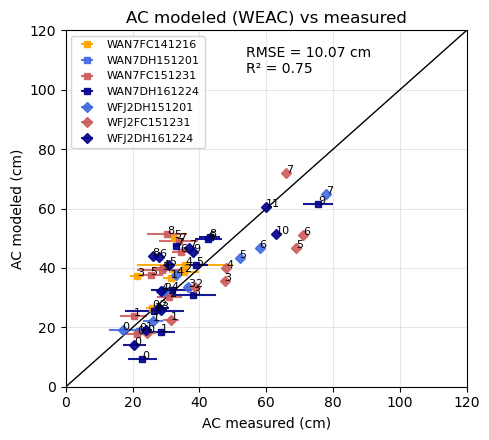

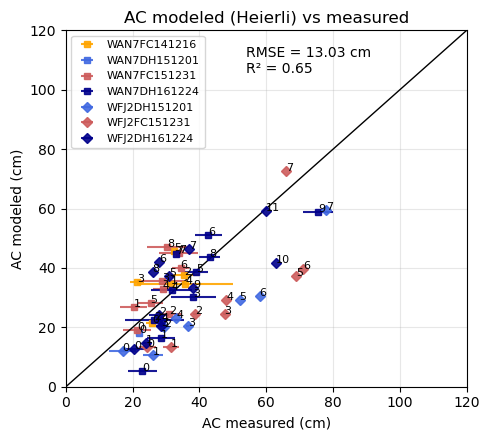

In [91]:
def interval_to_center_and_yerr(ac_interval, WL):
    ac_min, ac_max = zip(*ac_interval)
    ac_min = np.asarray(ac_min)
    ac_max = np.asarray(ac_max)

    ac_center = 0.5 * (ac_min + ac_max)

    if WL == "crocus":
        yerr = None
    else:
        yerr_low = ac_center - ac_min
        yerr_high = ac_max - ac_center
        yerr = np.vstack([yerr_low, yerr_high])

    return ac_center, yerr, ac_min, ac_max


def rmse_model(obs, mod, mod_min=None, mod_max=None):
    if mod_min is None or mod_max is None:
        return np.sqrt(np.mean((obs - mod) ** 2)), None, None

    rmse_min = np.sqrt(np.mean((obs - mod_max) ** 2))
    rmse_max = np.sqrt(np.mean((obs - mod_min) ** 2))
    rmse_c = np.sqrt(np.mean((obs - mod) ** 2))
    return rmse_c, rmse_min, rmse_max


def r2_model(obs, mod, mod_min=None, mod_max=None):
    if mod_min is None or mod_max is None:
        return np.corrcoef(obs, mod)[0, 1], None, None

    r2_min = np.corrcoef(obs, mod_min)[0, 1]
    r2_max = np.corrcoef(obs, mod_max)[0, 1]
    r2_c = np.corrcoef(obs, mod)[0, 1]
    return r2_c, r2_min, r2_max


def plot_ac_vs_obs(ac_interval, title, filename, WL):
    fig = plt.figure(figsize=(5, 4.5))
    ax = fig.add_subplot(1, 1, 1)

    # --- Storage for global metrics
    ls_obs = []
    ls_mod_center = []
    ls_mod_min = []
    ls_mod_max = []

    for site in start_date:
        for layer in start_date[site]:
            # ---------- Observations
            ac_obs = ds_PST[site][layer]["ac"].groupby("time").mean()
            ac_obs_std = ds_PST[site][layer]["ac"].groupby("time").std()

            # ---------- Modeled
            ac_center, yerr, ac_min, ac_max = interval_to_center_and_yerr(ac_interval[site][layer], WL)

            ax.errorbar(
                ac_obs,
                ac_center,
                xerr=ac_obs_std,
                yerr=yerr,
                fmt="o",
                markersize=5,
                marker=marker_site[site],
                color=color_layer[layer],
                label=site + layer,
                alpha=0.9,
            )

            # ---------- Storage for metrics
            ls_obs.append(ac_obs.values)
            ls_mod_center.append(ac_center)

            if WL != "crocus":
                ls_mod_min.append(ac_min)
                ls_mod_max.append(ac_max)

            # ---------- Time index annotation
            for i in range(len(ac_center)):
                ax.annotate(
                    str(i),
                    xy=(ac_obs[i], ac_center[i]),
                    fontsize=8,
                )

    # Scores
    obs_all = np.concatenate(ls_obs)
    mod_center_all = np.concatenate(ls_mod_center)

    if WL == "crocus":
        rmse, _, _ = rmse_model(obs_all, mod_center_all)
        r2, _, _ = r2_model(obs_all, mod_center_all)
    else:
        mod_min_all = np.concatenate(ls_mod_min)
        mod_max_all = np.concatenate(ls_mod_max)

        rmse, rmse_min, rmse_max = rmse_model(obs_all, mod_center_all, mod_min_all, mod_max_all)
        r2, r2_min, r2_max = r2_model(obs_all, mod_center_all, mod_min_all, mod_max_all)

    # Plot
    x = np.linspace(0, 120, 200)
    ax.plot(x, x, color="k", lw=1)

    if WL == "crocus":
        metrics_txt = f"RMSE = {rmse:.2f} cm\nR² = {r2:.2f}"
    else:
        metrics_txt = f"RMSE ∈ [{rmse_min:.2f}, {rmse_max:.2f}] cm\nR² ∈ [{r2_min:.2f}, {r2_max:.2f}]"

    ax.text(
        0.45,
        0.88,
        metrics_txt,
        transform=ax.transAxes,
        fontsize=10,
    )

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 120)
    ax.set_xlabel("AC measured (cm)")
    ax.set_ylabel("AC modeled (cm)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()


plot_ac_vs_obs(
    ac_interval=ac_W_interval,
    title="AC modeled (WEAC) vs measured",
    filename=output_path + f"AC_measured_vs_modeled_WEAC_uncertainty_{popt_weac}_{WL}_{fondation}_slope{inclination}.pdf",
    WL=WL,
)

plot_ac_vs_obs(
    ac_interval=ac_H_interval,
    title="AC modeled (Heierli) vs measured",
    filename=output_path + f"AC_measured_vs_modeled_HEIERLI_uncertainty_{popt_heierli}_{WL}_{fondation}_slope{inclination}.pdf",
    WL=WL,
)


## AC time series of WL (Crocus only) : Results 3.1

In [92]:
start_date = {
    "WAN7": {
        "FC141216": "2014-12-09",
        # "DH151201": "2015-11-26",
        "FC151231": "2015-12-12",
        "DH161224": "2016-12-15",
    },
    "WFJ2": {"DH151201": "2015-11-26", "FC151231": "2015-12-08", "DH161224": "2016-12-15"},
}

end_date = {
    "WAN7": {
        "FC141216": "2014-12-20T12",
        # "DH151201": "2015-12-05",
        "FC151231": "2015-12-20",
        "DH161224": "2016-12-25",
    },
    "WFJ2": {"DH151201": "2015-12-05", "FC151231": "2015-12-28", "DH161224": "2016-12-25"},
}


In [93]:
## Defined setup and output

# fondation = "E_t_default"
fondation = "EWL_t_default"
# fondation = "E_t_WL"

inclination = 0

popt_weac = float(popt_crocus)
popt_heierli = float(popt_crocus)

ac_W = {site: {} for site in list(start_date.keys())}
ac_H = {site: {} for site in list(start_date.keys())}
WL_charact = {site: {} for site in list(start_date.keys())}

for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ac_W[site][layer] = []
        ac_H[site][layer] = []
        ls_time = []

        ## Define timeline only where the weak layer exist
        timeline = ds_layer[site][layer]["WSN_VEG"].dropna(dim="time", how="all").resample(time="1D").nearest(tolerance="1D").time.values
        ds_layer[site][layer]["S_RHOWL"] = ds_layer[site][layer]["RSN_VEG"]
        ds_layer[site][layer]["S_HWL"] = ds_layer[site][layer]["SNOWDZ"]

        for time in timeline:
            WL_charact[site][layer] = ds_layer[site][layer].sel(time=time)
            profile_i = ds_slab[site][layer].sel(time=time).squeeze()[["RSN_VEG", "SNOWDZ"]].dropna(dim="snow_layer")
            rho, dz = profile_i["RSN_VEG"].values, profile_i["SNOWDZ"].values

            print(site, layer, time)

            if len(rho) == 0 or np.isnan(WL_charact[site][layer]["S_ELAYER"].values) == True:  ## If we don't have any slab infos for that date we pass that date
                pass
            else:
                ## Define WL characteristics (for WEAC model only)
                if fondation == "E_t_default":
                    E, t = 0.15, 20
                elif fondation == "EWL_t_default":
                    E, t = float(WL_charact[site][layer]["S_ELAYER"] / 1e6), float(30)
                elif fondation == "E_t_WL":
                    E, t = float(WL_charact[site][layer]["S_ELAYER"] / 1e6), float(WL_charact[site][layer]["S_HWL"] * 1e3)

                ## Compute WF using mincut param : WEAC

                wf = f_wf_mincut(
                    f_mincut_param(
                        WL_charact[site][layer]["S_RHOWL"] / 917,
                        WL_charact[site][layer]["SNOWSPHER"],
                        WL_charact[site][layer]["SNOWSSA"],
                    ),
                    popt_weac,
                )
                wf = float(wf)
                # wf = 0.25

                ## Compute AC and WF using weac
                wf_weac = [0.1]
                inf, sup = 1, 2000
                m = (inf + sup) / 2
                it = 0
                while (abs((wf_weac[0] - wf) / wf) > 0.01) and (abs(wf_weac[0] - wf) > 0.005):
                    ac_weac, wf_weac = compute_wf_weac(rho=rho, dz=dz, ac=[m], t=t, E=E, inclination=inclination)
                    if wf_weac[0] <= wf:
                        inf = m
                    else:
                        sup = m
                    m = (inf + sup) / 2
                    it = it + 1
                    if it > 100:  ## The algorithm doesn't converge
                        print("DIV")
                        break
                ac_W[site][layer].append(float(ac_weac[0] / 10))

                ## Compute AC at WF computed using Heierli model
                wf = f_wf_mincut(
                    f_mincut_param(
                        WL_charact[site][layer]["S_RHOWL"] / 917,
                        WL_charact[site][layer]["SNOWSPHER"],
                        WL_charact[site][layer]["SNOWSSA"],
                    ),
                    popt_heierli,
                )
                wf = float(wf)
                # wf = 0.25

                ac_heierli = compute_ac_heierli_from_profile(rho=rho, dz=dz, wf=wf, inclination=inclination)
                ac_H[site][layer].append(ac_heierli * 100)

                ls_time.append(time)

        ## Transform each list into dataarray
        ac_H[site][layer] = xr.DataArray(data=ac_H[site][layer], dims=["time"], coords=dict(time=ls_time))
        ac_W[site][layer] = xr.DataArray(data=ac_W[site][layer], dims=["time"], coords=dict(time=ls_time))


WAN7 FC141216 2014-12-09T00:00:00.000000000
WAN7 FC141216 2014-12-10T00:00:00.000000000
WAN7 FC141216 2014-12-11T00:00:00.000000000
WAN7 FC141216 2014-12-12T00:00:00.000000000
WAN7 FC141216 2014-12-13T00:00:00.000000000
WAN7 FC141216 2014-12-14T00:00:00.000000000
WAN7 FC141216 2014-12-15T00:00:00.000000000
WAN7 FC141216 2014-12-16T00:00:00.000000000
WAN7 FC141216 2014-12-17T00:00:00.000000000
WAN7 FC141216 2014-12-18T00:00:00.000000000
WAN7 FC141216 2014-12-19T00:00:00.000000000
WAN7 FC141216 2014-12-20T00:00:00.000000000
WAN7 FC141216 2014-12-21T00:00:00.000000000
WAN7 FC141216 2014-12-22T00:00:00.000000000
WAN7 FC141216 2014-12-23T00:00:00.000000000
WAN7 FC141216 2014-12-24T00:00:00.000000000
WAN7 FC141216 2014-12-25T00:00:00.000000000
WAN7 FC141216 2014-12-26T00:00:00.000000000
WAN7 FC141216 2014-12-27T00:00:00.000000000
WAN7 FC141216 2014-12-28T00:00:00.000000000
WAN7 FC141216 2014-12-29T00:00:00.000000000
WAN7 FC141216 2014-12-30T00:00:00.000000000
WAN7 FC141216 2014-12-31T00:00:0

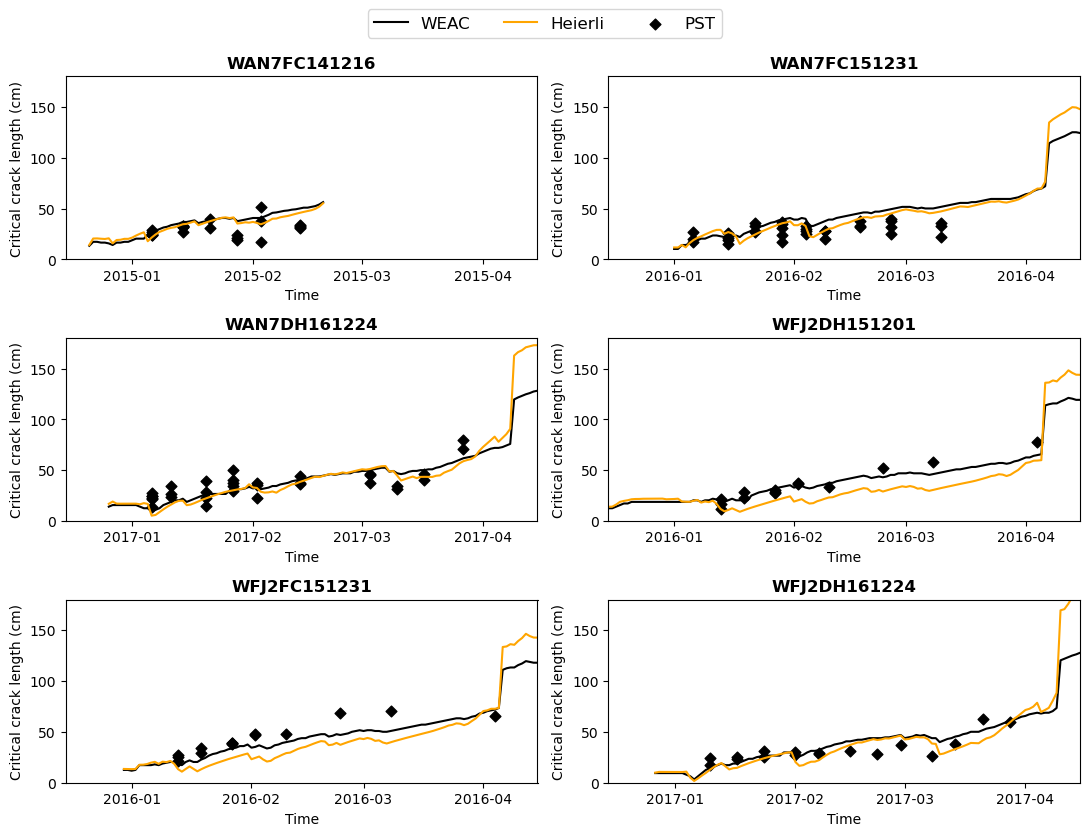

In [94]:
### AC OBS vs MOD time series
import matplotlib.dates as mdates

fig = plt.figure(figsize=(11, 8))

it = 1
for site in list(start_date.keys()):
    for layer in list(start_date[site].keys()):
        ax = fig.add_subplot(len(list(start_date["WAN7"].keys())), len(list(start_date.keys())), it)

        ac_mes = ds_PST[site][layer]["ac"]
        ac_mod = ac_W[site][layer]

        ax.plot(ac_mod.time, ac_mod, label="WEAC", color="black", lw=1.5)

        ac_mod = ac_H[site][layer]
        ax.plot(ac_mod.time, ac_mod, label="Heierli", color="orange", lw=1.5)
        ax.set_title(site + layer, fontweight="bold")
        ax.scatter(ac_mes.time, ac_mes, marker="D", s=30, color="k", label="PST")
        ax.set_ylabel("Critical crack length (cm)")
        ax.set_xlabel("Time")

        ax.set_xlim(pd.to_datetime(str(ac_mod.time[-1].dt.year.values - 1) + "-12-15"), pd.to_datetime(str(ac_mod.time[-1].dt.year.values) + "-04-15"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.set_ylim(0, 180)

        it = it + 1
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.25, 0.55, 0.5, 0.5), ncol=3, fontsize="large", fancybox=True, frameon=True)

plt.savefig(output_path + "Time_series_AC_measured_vs_modeled_" + fondation + "_slope" + str(inclination) + ".pdf", dpi=300, bbox_inches="tight")

## AC at manual profiles (Crocus and OBS) : Results 3.2

In [ ]:
def get_E_t(fondation, WL_charact_i):
    if fondation == "E_t_default":
        return 0.15, 20
    elif fondation == "EWL_t_default":
        return float(WL_charact_i["S_ELAYER"] / 1e6), 30.0
    elif fondation == "E_t_WL":
        return (
            float(WL_charact_i["S_ELAYER"] / 1e6),
            float(WL_charact_i["S_HWL"] * 1e3),
        )


def compute_wf(WL_charact_i, popt):
    wf = f_wf_mincut(
        f_mincut_param(
            WL_charact_i["S_RHOWL"] / 917,
            WL_charact_i["SNOWSPHER"],
            WL_charact_i["SNOWSSA"],
        ),
        popt,
    )
    return float(wf)


def invert_ac_weac(rho, dz, wf_target, E, t, inclination):
    inf, sup = 1, 2000
    m = (inf + sup) / 2

    ac_weac, wf_weac = compute_wf_weac(rho=rho, dz=dz, ac=[m], t=t, E=E, inclination=inclination)

    it = 0
    while abs((wf_weac[0] - wf_target) / wf_target) > 0.01 and abs(wf_weac[0] - wf_target) > 0.005:
        if wf_weac[0] <= wf_target:
            inf = m
        else:
            sup = m

        m = (inf + sup) / 2
        ac_weac, wf_weac = compute_wf_weac(rho=rho, dz=dz, ac=[m], t=t, E=E, inclination=inclination)

        it += 1
        if it > 100:
            print("DIV")
            break

    return float(ac_weac[0] / 10)


def set_manual_snow_microstructure(WL_charact_i, grain_intervals):
    dict_conv = {1: "PP", 2: "DF", 3: "RG", 4: "FC", 5: "DH", 6: "DH", 7: "MF", 8: "MF", 9: "FCxr", 10: "MFcr"}

    grain_code = dict_conv[int(WL_charact_i["grain_type"].values)]
    grain_key = grain_code[:2]

    WL_charact_i["SNOWSPHER"] = np.mean(grain_intervals.loc[grain_key]["S"])
    WL_charact_i["SNOWSSA"] = np.mean(grain_intervals.loc[grain_key]["G"])


def compute_ac_profile(
    profile_i,
    WL_charact_i,
    fondation,
    inclination,
    *,
    manual=False,
    grain_intervals=None,
):
    rho = profile_i["RSN_VEG"].values
    dz = profile_i["SNOWDZ"].values

    if len(rho) == 0:
        return np.nan, np.nan

    # WL characteristics
    WL_charact_i["S_ELAYER"] = E_modulus(WL_charact_i["RSN_VEG"])
    WL_charact_i["S_HWL"] = WL_charact_i["SNOWDZ"]
    WL_charact_i["S_RHOWL"] = WL_charact_i["RSN_VEG"]

    # MANUAL microstructure
    if manual:
        set_manual_snow_microstructure(WL_charact_i, grain_intervals)

    # Fondation
    E, t = get_E_t(fondation, WL_charact_i)

    # WEAC
    wf_weac = compute_wf(WL_charact_i, popt_weac)
    ac_weac = invert_ac_weac(rho, dz, wf_weac, E, t, inclination)

    # Heierli
    wf_heierli = compute_wf(WL_charact_i, popt_heierli)
    ac_heierli = compute_ac_heierli_from_profile(rho=rho, dz=dz, wf=wf_heierli, inclination=inclination) * 100

    return ac_weac, ac_heierli


#######################
### Manual profiles ###
#######################

ac_W_Obs = {site: {} for site in start_date}
ac_H_Obs = {site: {} for site in start_date}
ds_manual = {site: ds_manual_complete[site].groupby("time").mean() for site in start_date}

for site in start_date:
    for time in np.unique(ds_manual[site].time):
        time_str = pd.to_datetime(time).strftime("%Y%m%d")
        print(site, time_str)

        ac_W_Obs[site][time_str] = []
        ac_H_Obs[site][time_str] = []

        strati = ds_manual[site].sel(time=time_str).dropna(dim="depth", how="all")

        for j in range(1, len(strati.depth)):
            profile_i = strati[["RSN_VEG", "SNOWDZ"]].isel(depth=slice(0, j))
            WL_charact_i = strati[["RSN_VEG", "SNOWDZ", "grain_type"]].isel(depth=j)

            ac_w, ac_h = compute_ac_profile(
                profile_i,
                WL_charact_i,
                fondation,
                inclination,
                manual=True,
                grain_intervals=grain_intervals,
            )

            ac_W_Obs[site][time_str].append(ac_w)
            ac_H_Obs[site][time_str].append(ac_h)

        ac_W_Obs[site][time_str] = xr.DataArray(
            ac_W_Obs[site][time_str],
            dims=["depth"],
            coords=dict(depth=strati.depth[1:]),
        )
        ac_H_Obs[site][time_str] = xr.DataArray(
            ac_H_Obs[site][time_str],
            dims=["depth"],
            coords=dict(depth=strati.depth[1:]),
        )


#######################
### Crocus profiles ###
#######################

ac_W_Crocus = {site: {} for site in start_date}
ac_H_Crocus = {site: {} for site in start_date}

for site in start_date:
    for time in np.unique(ds_manual_complete[site].time):
        time_str = pd.to_datetime(time).strftime("%Y%m%d")
        print(site, time_str)

        ac_W_Crocus[site][time_str] = []
        ac_H_Crocus[site][time_str] = []

        strati = ds[site].sel(time=time_str + "T12")[["RSN_VEG", "SNOWDZ", "SNOWSPHER", "SNOWSSA"]].dropna(dim="snow_layer", how="all")

        for j in range(1, len(strati.snow_layer)):
            profile_i = strati[["RSN_VEG", "SNOWDZ"]].isel(snow_layer=slice(0, j))
            WL_charact_i = strati[["RSN_VEG", "SNOWDZ", "SNOWSPHER", "SNOWSSA"]].isel(snow_layer=j)

            ac_w, ac_h = compute_ac_profile(
                profile_i,
                WL_charact_i,
                fondation,
                inclination,
                manual=False,
            )

            ac_W_Crocus[site][time_str].append(ac_w)
            ac_H_Crocus[site][time_str].append(ac_h)

        ac_W_Crocus[site][time_str] = xr.DataArray(
            ac_W_Crocus[site][time_str],
            dims=["snow_layer"],
            coords=dict(snow_layer=strati.snow_layer[1:]),
        )
        ac_H_Crocus[site][time_str] = xr.DataArray(
            ac_H_Crocus[site][time_str],
            dims=["snow_layer"],
            coords=dict(snow_layer=strati.snow_layer[1:]),
        )


WAN7 20150106
WAN7 20150114
WAN7 20150121
WAN7 20150128
WAN7 20150203
WAN7 20150213
WAN7 20160106
WAN7 20160115
WAN7 20160122
WAN7 20160129
WAN7 20160204
WAN7 20160209
WAN7 20160218
WAN7 20160226
WAN7 20160310
WAN7 20170106
WAN7 20170111
WAN7 20170120
WAN7 20170127
WAN7 20170202
WAN7 20170213
WAN7 20170303
WAN7 20170310
WAN7 20170317
WAN7 20170327
WFJ2 20160113
WFJ2 20160119
WFJ2 20160127
WFJ2 20160202
WFJ2 20160210
WFJ2 20160224
WFJ2 20160308
WFJ2 20160404
WFJ2 20170110
WFJ2 20170117
WFJ2 20170124
WFJ2 20170201
WFJ2 20170207
WFJ2 20170215
WFJ2 20170222
WFJ2 20170228
WFJ2 20170308
WFJ2 20170314
WFJ2 20170321
WFJ2 20170328
WAN7 20150106
WAN7 20150114
WAN7 20150121
WAN7 20150128
WAN7 20150203
WAN7 20150213
WAN7 20160106
WAN7 20160115
WAN7 20160122
WAN7 20160129
WAN7 20160204
WAN7 20160209
WAN7 20160218
WAN7 20160226
WAN7 20160310
WAN7 20170106
DIV
DIV
WAN7 20170111
WAN7 20170120


### Selected profiles

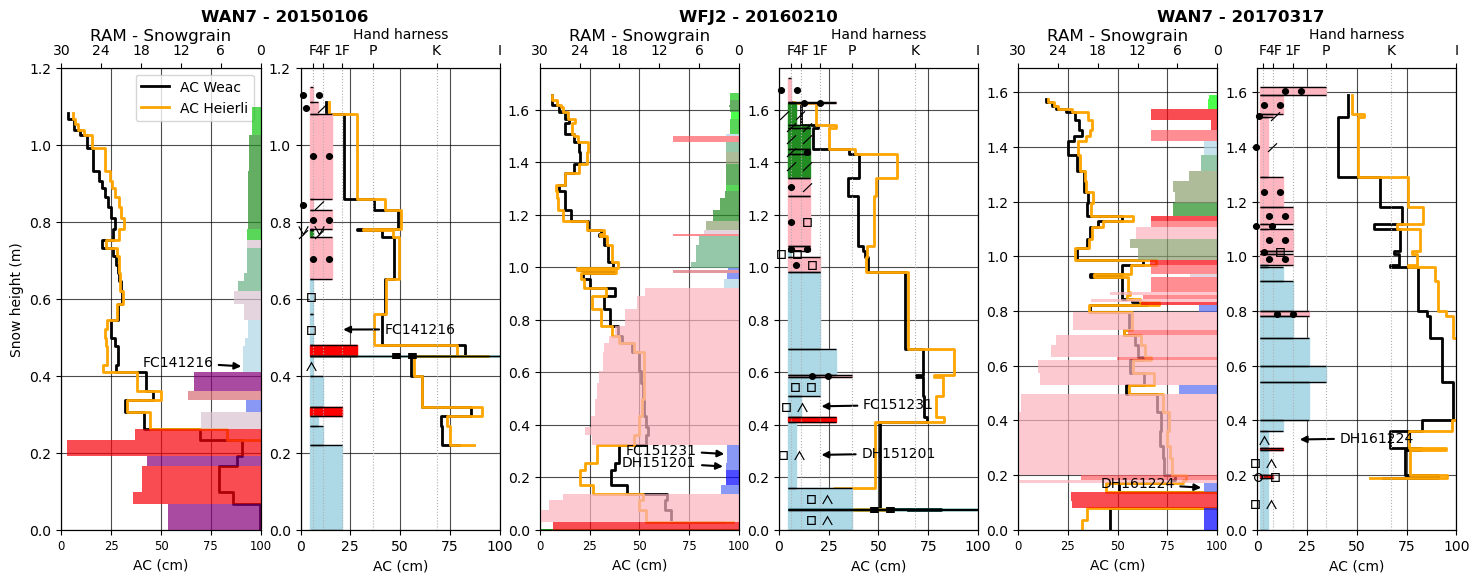

In [86]:
selected_time = {"WAN7-2015": ["20150106"], "WFJ2-2016": ["20160210"], "WAN7-2017": ["20170317"]}


fig = plt.figure(figsize=(18, 6))
it = 1

for site in selected_time.keys():
    for time in selected_time[site]:
        site = site[0:4]

        ######################
        ### Simulated profiles
        ######################

        ds_i = ds[site].sel(time=time + "T12")
        ds_i["snow_layer"] = np.arange(0, 50, 1)

        ## Affect new AC computed to current dataset
        ds_i["AC_WEAC"] = ac_W_Crocus[site][time].reindex_like(ds_i["RSN_VEG"])
        ds_i["AC_HEIERLI"] = ac_H_Crocus[site][time].reindex_like(ds_i["RSN_VEG"])

        ylim = np.round(np.sum(ds_i["SNOWDZ"]), 2) + 0.1
        ax = fig.add_subplot(1, 6, it)
        it += 1
        ax2 = ax.twiny()
        dateProfil(ax, ax2, value=ds_i["RSN_VEG"] * 100, value_dz=ds_i["SNOWDZ"].fillna(0).values, value_grain=ds_i["SNOWTYPE"].values, value_ram=ds_i["SNOWRAM"].values, color="green")

        ax.set_ylim(0, ylim)
        ax.set_xlim(0, 100)
        ax.grid(True, color="k", alpha=0.7)

        ## Plot the AC computed using either Weac or Heierli model
        ax.step(x=ds_i["AC_WEAC"], y=np.cumsum(ds_i["SNOWDZ"][::-1])[::-1], color="k", lw=2, where="pre", label="AC Weac")
        ax.step(x=ds_i["AC_HEIERLI"], y=np.cumsum(ds_i["SNOWDZ"][::-1])[::-1], color="orange", lw=2, where="pre", label="AC Heierli")
        ax.set_xlabel("AC (cm)")

        if it == 2:
            ax.set_ylabel("Snow height (m)")
            ax.legend()

        ## Add followed WL
        for layer in list(start_date[site].keys()):
            x, ytop = (
                ds_layer[site][layer].sel(time=time)["SNOWRAM"].mean(dim="time"),
                ds_layer[site][layer].sel(time=time)["top_depth"].mean(dim="time"),
            )
            y = ytop - ds_layer[site][layer].sel(time=time)["SNOWDZ"].mean(dim="time") / 2
            ax2.annotate(
                layer,
                xy=(x, y),
                xytext=(x + 10, y),
                horizontalalignment="center",
                arrowprops=dict(arrowstyle="-|>", color="k", lw=1.5, ls="-"),
            )

        ######################
        ### Manual profiles
        ######################

        strati = ds_manual_complete[site].drop_duplicates(dim="time").sel(time=time).dropna(dim="depth", how="all")

        ## Affect new var to it
        strati["AC_WEAC"] = ac_W_Obs[site][time]
        strati["AC_HEIERLI"] = ac_H_Obs[site][time]

        stratiprofile = snowprofile.profiles.Stratigraphy(
            data={
                "grain_1": strati["grain_type1"],
                "grain_2": strati["grain_type2"],
                "top_height": strati["depth"],
                "thickness": strati["SNOWDZ"],
                "hardness": strati["hand_hardness"],
                "grain_size": None,
                "wetness": None,
            }
        )

        ax = fig.add_subplot(1, 6, it)
        it += 1

        ax.step(x=strati["AC_WEAC"], y=strati["depth"], color="k", lw=2, where="pre", label="AC Weac")
        ax.step(x=strati["AC_HEIERLI"], y=strati["depth"], color="orange", lw=2, where="pre", label="AC Heierli")
        ax.set_xlim(0, 100)
        ax.grid(True, color="k", alpha=0.7)
        ax.set_xlabel("AC (cm)")

        ax2 = ax.twiny()
        snowprofile.plot.plot_utils.plot_strati_profile(ax2, stratiprofile, xlabel="Hand harness", ylabel="Height (m)", grain_labels=True, use_hardness=True)
        # ax.legend()
        ax2.set_ylim(0, ylim)

        ## Add followed WL
        ## Load PST measurements
        for layer in list(start_date[site].keys()):
            if pd.to_datetime(time) in ds_PST[site][layer].time:
                x, ytop = 20, ds_PST[site][layer]["depth"].sel(time=time).values.mean() / 100
                # Find the corresponding depth in the layer charact
                idx = (np.abs(strati["depth"] - ytop)).argmin()
                y = strati["depth"][idx] - strati["SNOWDZ"][idx] / 2
                ax.annotate(
                    layer,
                    xy=(x, y),
                    xytext=(x + 40, y - 0.01),
                    horizontalalignment="center",
                    arrowprops=dict(arrowstyle="-|>", color="k", lw=1.5, ls="-"),
                )
        ax.text(x=-0.5, y=1.1, s=site + " - " + time, fontweight="bold", fontsize=12, transform=ax.transAxes)

plt.savefig(output_path + "Selected_profile_OBS_vs_Modeled_WEAC_HEIERLI_slope_" + str(inclination) + ".pdf", bbox_inches="tight")
